In [1]:
import stochastic_model.src as src
from matplotlib import pyplot as plt

SM = src.StochasticModel

In [2]:
model = SM("TSLA","heston")
model.fetch_market_data(expiries=model.fetch_expiries()[:5], save_to_class=True, save_to_csv="option_data.csv", atm_threshold=0.10, min_open_interest=2000)

Initialized a heston model for TSLA
Fetching expiries for traded options of TSLA
Fetching market traded options for TSLA for expiry at ('2026-03-02', '2026-03-04', '2026-03-06', '2026-03-13', '2026-03-20')
Fetched data are filtered for min 2000 open interest and max 10.0% moneyness threshold


,strike,lastPrice,impliedVolatility,side,expiry,T
0,410.0,1.34,0.336432,Call,2026-03-02,0.008
1,415.0,0.56,0.341803,Call,2026-03-02,0.008
2,420.0,0.22,0.348639,Call,2026-03-02,0.008
3,430.0,0.03,0.382819,Call,2026-03-02,0.008
4,385.0,0.52,0.449224,Put,2026-03-02,0.008
5,390.0,0.91,0.411871,Put,2026-03-02,0.008
6,392.5,1.22,0.396002,Put,2026-03-02,0.008
7,395.0,1.58,0.381354,Put,2026-03-02,0.008
8,400.0,3.05,0.357672,Put,2026-03-02,0.008
9,410.0,3.59,0.387701,Call,2026-03-04,0.016


In [ ]:
r = 0.0372
model.model="black_scholes"
model.quick_calibration(model.data, r, ((0.01,1),), max_calls=100, print_report=True, print_step=10, error_type="mse")
model.batch_price_option(model.data, r=r, params=model.best_params[0], return_column="BS_predictions")

Fetching last underlying price of TSLA
Quick calibration over 100 steps, total 100 calls...
- Step 0:  best params: [0.01]  |  Min error: [0.835]
- Step 10:  best params: [0.11]  |  Min error: [0.75]
- Step 20:  best params: [0.21]  |  Min error: [0.447]
- Step 30:  best params: [0.31]  |  Min error: [0.072]
- Step 40:  best params: [0.32]  |  Min error: [0.065]
- Step 50:  best params: [0.32]  |  Min error: [0.065]
- Step 60:  best params: [0.32]  |  Min error: [0.065]
- Step 70:  best params: [0.32]  |  Min error: [0.065]
- Step 80:  best params: [0.32]  |  Min error: [0.065]
- Step 90:  best params: [0.32]  |  Min error: [0.065]
 Lowest error reached:  [0.06542048]
 Optimal parameters:    [0.32]


In [ ]:
model.model  = "heston"
heston_calib = model.calibrate(model.data, r, x0=[0.3,0.13,3,-0.5,0.03], print_report=True, print_step=100,
                bounds = [(0.1, 3), (0.001, 0.7), (0.001, 2), (-1, 1), (0.01, 0.3)], error_type="mse")
model.batch_price_option(model.data, r=r, params=model.best_params, return_column="Heston_predictions")

Fetching last underlying price of TSLA
Calibrating the function...
- Step 0:  best params: [ 0.3   0.13  2.   -0.5   0.03]  |  Min error: 0.589
- Step 100:  best params: [ 0.3116399   0.17553407  1.98827497 -0.36207809  0.11349852]  |  Min error: 0.046
- Step 200:  best params: [ 0.52331923  0.7         1.88529456 -0.34230386  0.11111691]  |  Min error: 0.037
- Step 300:  best params: [ 1.79572983  0.68355979  2.         -0.33828842  0.10160373]  |  Min error: 0.026
 Lowest error reached:  0.026387088464855296
 Optimal parameters:    [ 1.74885521  0.7         2.         -0.33815936  0.10152922]


In [ ]:
model.model  = "bates"
bates_calib = model.calibrate(model.data, r, x0=[3,0.3,2,-0.3,0.1,0.05,-0.15,0.3], print_report=True, print_step=100,
                bounds = [(0.1, 4), (0.001, 0.7), (0.001, 3), (-1, 1), (0.01, 0.3),
                          (0.001, 2), (-0.3,0.3), (0.01,1)], error_type="mse")
model.batch_price_option(model.data, r=r, params=model.best_params, return_column="Bates_predictions")

Fetching last underlying price of TSLA
Calibrating the function...
- Step 0:  best params: [ 3.    0.3   2.   -0.3   0.1   0.05 -0.15  0.3 ]  |  Min error: 0.031
- Step 100:  best params: [ 3.00912515  0.4476548   2.0150556  -0.36385772  0.09950471  0.06509569
 -0.20576874  0.26687628]  |  Min error: 0.025
- Step 200:  best params: [ 3.00609235  0.43055295  2.09762834 -0.24322781  0.09373403  0.2806663
 -0.3         0.23273217]  |  Min error: 0.021
- Step 300:  best params: [ 2.99408725  0.32234423  2.27410462  0.08528563  0.07284145  0.82842892
 -0.24859537  0.02270783]  |  Min error: 0.012
- Step 400:  best params: [ 2.99180235  0.31532505  2.3251921   0.06873509  0.07224552  1.33593185
 -0.18092484  0.01      ]  |  Min error: 0.012
 Lowest error reached:  0.011732486804904633
 Optimal parameters:    [ 2.99189725  0.31829333  2.32722933  0.0647232   0.07229436  1.36456374
 -0.17887317  0.01      ]


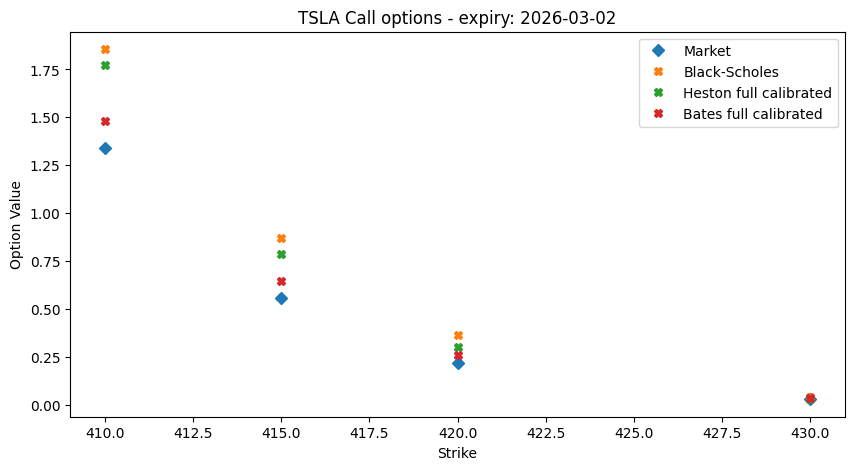

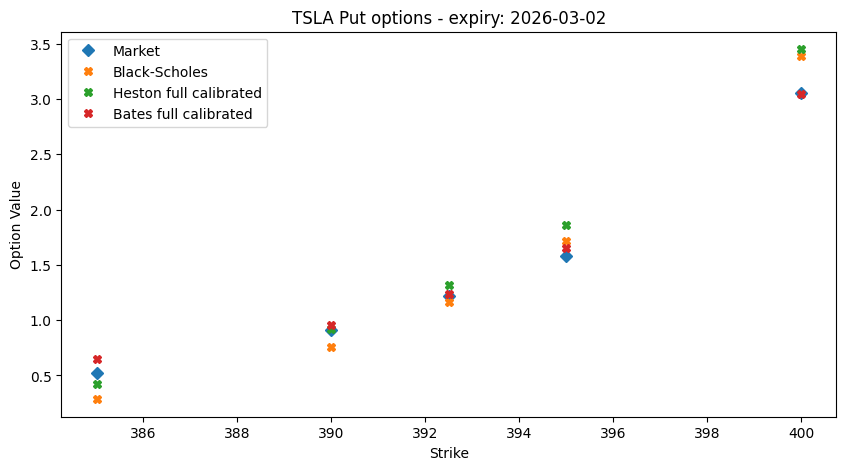

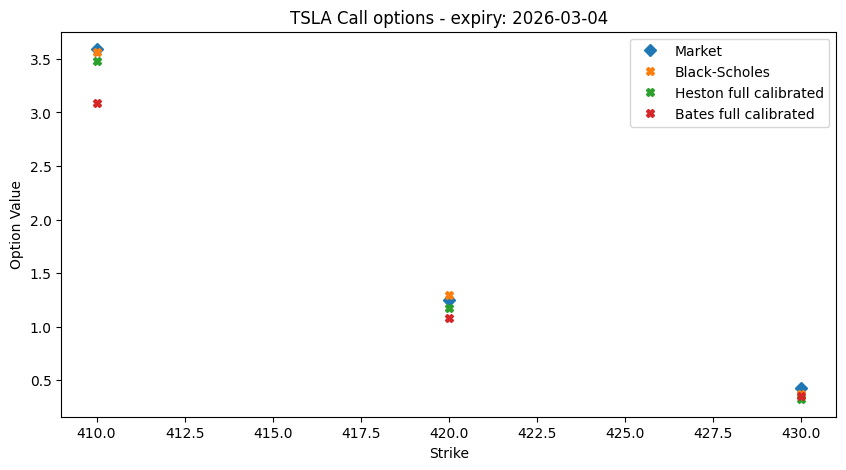

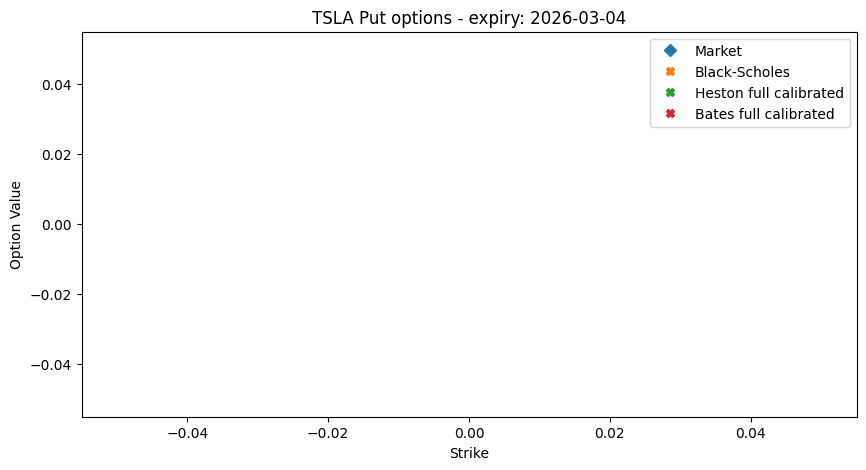

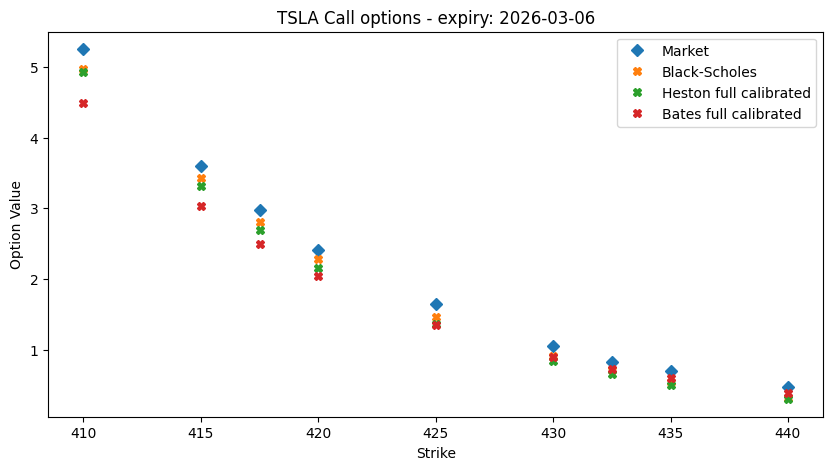

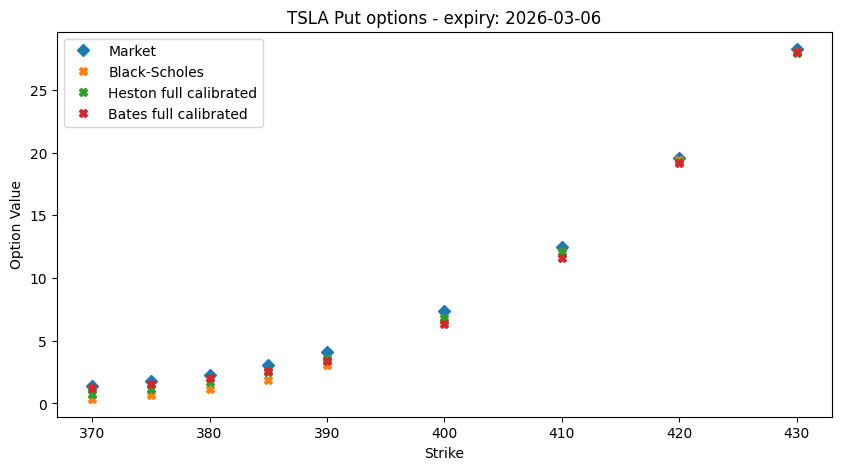

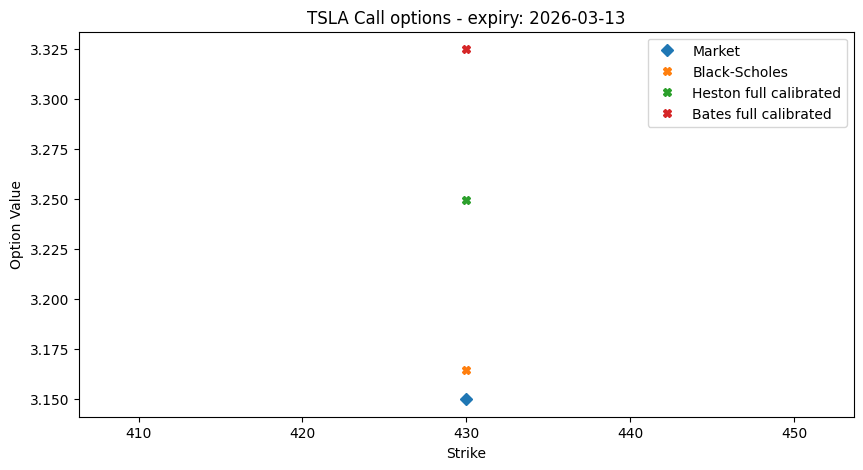

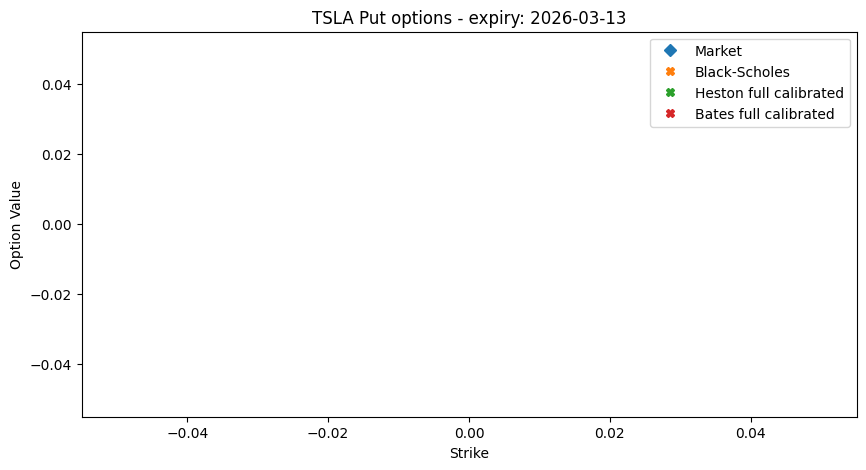

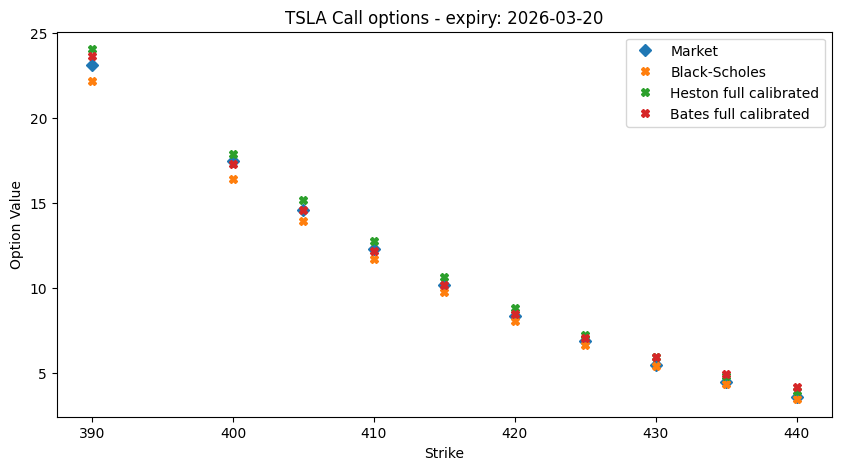

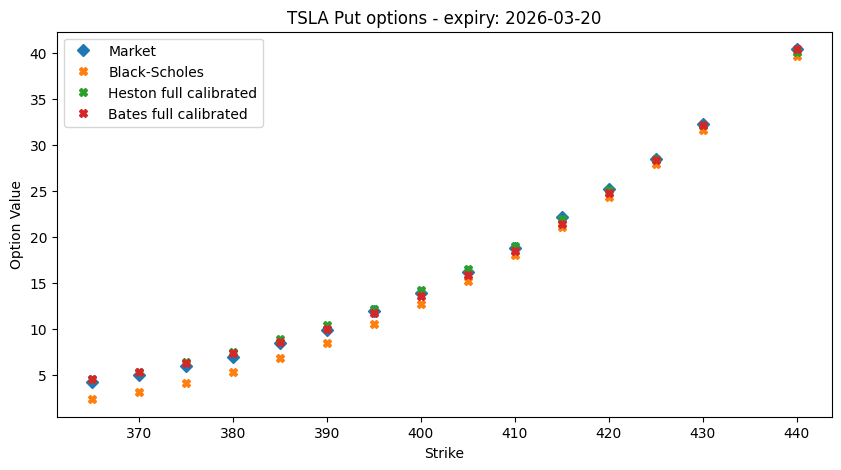

In [6]:
def plot_data(data, columns, labels, title):
    plt.figure(figsize=(10,5))
    for i in range(len(labels)):
        plt.plot(data["strike"], data[columns[i]], "D" if i==0 else "X", label=labels[i])
        plt.legend()
        plt.ylabel("Option Value")
        plt.xlabel("Strike")
        plt.title(title)

for expiry in model.data["expiry"].unique():
    for side in ["Call", "Put"]:
        options_df = model.data.query("expiry == @expiry and side == @side")
        plot_data(options_df,
                  columns=["lastPrice", "BS_predictions", "Heston_predictions", "Bates_predictions"],
                  labels=["Market", "Black-Scholes", "Heston full calibrated", "Bates full calibrated"],
                  title=f"{model.ticker} {side} options - expiry: {expiry}")